In [11]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

In [12]:
# params / initialization

# number of independent lambs
R = int(2e4)
# steps
T = int(1e4)
# initial location of lion
d0 = 10
# continuum prediction
S1 = lambda t: sc.special.erf(d0/(2*np.sqrt(t)))

# lambds start at 0
lamb_pos = np.zeros(R)
lion_pos = np.full(R, d0)
capture_time = np.full(R, T+1)

In [13]:
# loop
for t in range(T):
    # check which ones are still going
    active = capture_time > T

    # move the animals
    lamb_step = np.where(np.random.uniform(0,1, size=R) < 0.5, -1, 1)
    lion_step = np.where(np.random.uniform(0,1, size=R) < 0.5, -1, 1)

    # update their positions
    lamb_pos += lamb_step
    lion_pos += lion_step

    # check if newly captured
    captured = active & (lamb_pos == lion_pos)
    capture_time[captured] = t

In [27]:
# process stuff
times = np.arange(1,T+1)
S1_exp = np.array([np.mean(capture_time > s) for s in times])

# silly little mask to silly little follow the problem
fit_bounds = ((times >= int(1e2)) & (times <= int(1e4)))
fit_times = times[fit_bounds]
fit_S1 = S1_exp[fit_bounds]

# fit power law using logs
polynomial = np.polyfit(np.log10(fit_times), np.log10(fit_S1), deg=1)
slope = polynomial[0]
intercept = polynomial[1]
beta = -slope
line = lambda t: 10**(intercept) * t**(slope)

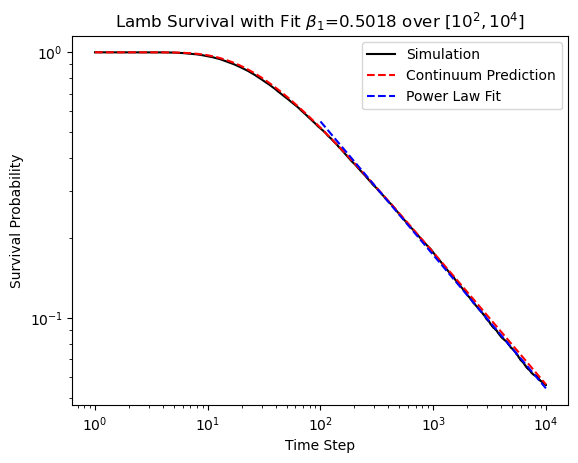

In [36]:
# plotting
plt.loglog(times, S1_exp, 'k-', label='Simulation')
plt.loglog(times, S1(times), 'r--', label='Continuum Prediction')
plt.loglog(fit_times, line(fit_times), 'b--', label='Power Law Fit')
plt.title(f"Lamb Survival with Fit $\\beta_1$={beta:.4f} over $[10^2,10^4]$")
plt.xlabel('Time Step')
plt.ylabel('Survival Probability')
plt.legend()

In [42]:
# rerun of simulation
lamb_pos = np.zeros(R)
lion1_pos = np.full(R, d0)
lion2_pos = np.full(R, d0)
capture_time_new = np.full(R, T+1)

# loop
for t in range(T):
    # check which ones are still going
    active = capture_time_new > T

    # move the animals
    lamb_step = np.where(np.random.uniform(0,1, size=R) < 0.5, -1, 1)
    lion1_step = np.where(np.random.uniform(0,1, size=R) < 0.5, -1, 1)
    lion2_step = np.where(np.random.uniform(0,1, size=R) < 0.5, -1, 1)

    # update their positions
    lamb_pos += lamb_step
    lion1_pos += lion1_step
    lion2_pos += lion2_step

    # check if newly captured
    captured = active & ((lamb_pos == lion1_pos) | (lamb_pos == lion2_pos))
    capture_time_new[captured] = t

S2_exp = np.array([np.mean(capture_time_new > s) for s in times])
fit_S2 = S2_exp[fit_bounds]

# fit power law using logs
polynomial2 = np.polyfit(np.log10(fit_times), np.log10(fit_S2), deg=1)
slope2 = polynomial2[0]
intercept2 = polynomial2[1]
beta2 = -slope2
line2 = lambda t: 10**(intercept2) * t**(slope2)

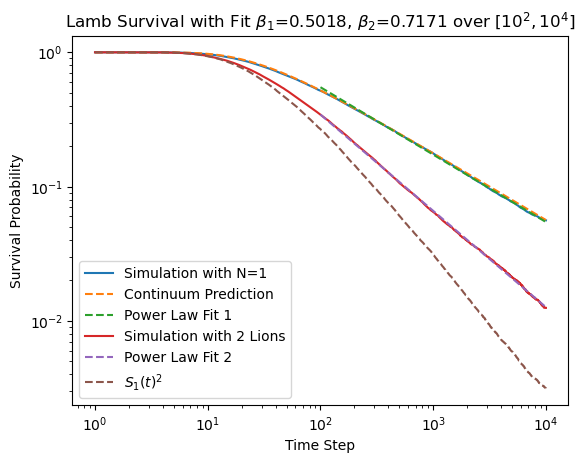

In [45]:
# full plot
plt.loglog(times, S1_exp, '-', label='Simulation with N=1')
plt.loglog(times, S1(times), '--', label='Continuum Prediction')
plt.loglog(fit_times, line(fit_times), '--', label='Power Law Fit 1')
plt.loglog(times, S2_exp, '-', label='Simulation with 2 Lions')
plt.loglog(fit_times, line2(fit_times), '--', label='Power Law Fit 2')
plt.loglog(times, S1_exp**2, '--', label='$S_1(t)^2$')
plt.title(f"Lamb Survival with Fit $\\beta_1$={beta:.4f}, $\\beta_2$={beta2:.4f} over $[10^2,10^4]$")
plt.xlabel('Time Step')
plt.ylabel('Survival Probability')
plt.legend()

In [69]:
# values:
print("| -------- | -------- | -------- | -------- |")
print(f"| -------- | - 10^2 - | - 10^3 - | - 10^4 - |")
print(f"| S_2(t)   |  {S2_exp[99]:<8.4f}|  {S2_exp[999]:<8.4f}|  {S2_exp[9999]:<8.4f}|")
print(f"| S_1(t)^2 |  {S1_exp[99]**2:<8.4f}|  {S1_exp[999]**2:<8.4f}|  {S1_exp[9999]**2:<8.4f}|")
print("| -------- | -------- | -------- | -------- |")

| -------- | -------- | -------- | -------- |
| -------- | - 10^2 - | - 10^3 - | - 10^4 - |
| S_2(t)   |  0.3439  |  0.0649  |  0.0125  |
| S_1(t)^2 |  0.2678  |  0.0312  |  0.0031  |
| -------- | -------- | -------- | -------- |
